<a href="https://colab.research.google.com/github/penajuanmanuel6-hub/automated-etl-pipeline/blob/main/Inventarios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  bodega_destino  stock_unidades
0         Bogota             270
1           Cali             480
2       Medellin             450


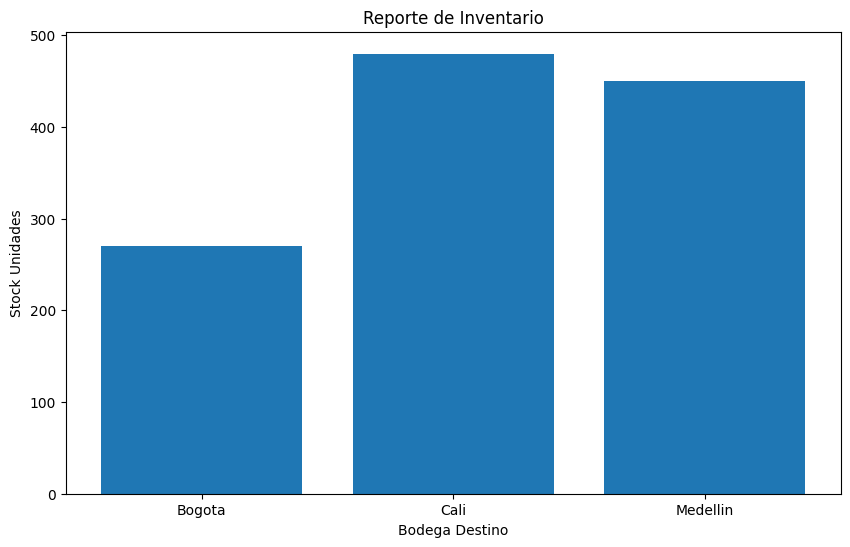

In [11]:
# Ejercicio de Inventarios

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

datos_inventario=pd.DataFrame({"id_producto": [201, 202, 203, 204, 205, 206],
    "bodega_destino": ['Bogota', 'Medellin', 'Bogota', 'Cali', 'Medellin', 'Cali'],
    "stock_unidades": [150, 200, 120, 300, 250, 180]})

# Conexión y Configuración (Raíz)
def connect():
  engine=sqlite3.connect(":memory:")
  return engine
#Extracción de datos con SQL (Rama)

def extraer_datos(query,conexion):
  df_resultado=pd.read_sql(query,conexion)
  return df_resultado

#Limpieza y transformación de datos (Ramas)
def limpiar_datos(df):
  df=df.drop_duplicates()
  df["stock_unidades"]=df.groupby("bodega_destino")["stock_unidades"].transform(lambda x: x.fillna(x.mean))
  return df

#Generar reporte (hojas y frutos)
def generar_reporte(df):
  resumen=df.groupby("bodega_destino")["stock_unidades"].sum().reset_index()
  print(resumen)
  return resumen

#Orquestación (Tronco)
if __name__=="__main__":
  conexion=connect()
  datos_inventario.to_sql("datos_inventario", conexion, if_exists="replace", index=False)
  sql="SELECT * FROM datos_inventario;"
  df_crudos=extraer_datos(sql,conexion)
  df_limpios=limpiar_datos(df_crudos)
  resumen=generar_reporte(df_limpios)

plt.figure(figsize=(10,6))
plt.bar(resumen["bodega_destino"], resumen["stock_unidades"])
plt.xlabel("Bodega Destino")
plt.ylabel("Stock Unidades")
plt.title("Reporte de Inventario")
plt.show()



